In [1]:
import jupyter_black
jupyter_black.load()

import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from tqdm import tqdm

from ccl_science_data.common import get_arr, EntC, GenReader

loading  /home/borza/rankless/.env
OA_ROOT:  /home/borza/rankless-data
SNAP_ROOT:  /mnt/hdd/shared/openalex-snapshot-2025-10


In [2]:
ns_rex = re.compile('impl NamespacedEntity for (.*) { const NS: & str = "(.*)"; }')

In [3]:
fgrs = ""
for grs in Path("../rankless_rs/src/gen/").iterdir():
    fgrs += "\n" + grs.read_text()

In [4]:
nsents = ns_rex.findall(fgrs)

In [5]:
numents = []
arrents = []
sdtmap = {}
for en, ns in nsents:
    numents += [
        [*e, ns]
        for e in re.findall(
            f'impl Entity for {en} {{ type T = u(\d+); const N: usize = \d+; const NAME: & str = "(.*)"; }}',
            fgrs,
        )
    ]
    for dtn, ename in re.findall(
        f'impl Entity for {en} {{ type T = Box<\[u(\d+)\]>; const N: usize = \d+; const NAME: & str = "(.*)"; }}',
        fgrs,
    ):
        arrents.append([dtn, ename, ns])
        sdtmap[ename] = re.findall(
            f"impl VariableSizeAttribute for {en} {{ type SizeType = u(\d+); type LocType = .*; }}",
            fgrs,
        )[0]

In [6]:
defs = ""
for dtn, en, ns in numents:
    defs += f"""
def larr_{en.replace('-', '_')}():
    return get_arr( "{ns}/{en}", {dtn} )    
"""

for dtn, en, ns in arrents:
    defs += f"""
def lvarr_{en.replace('-', '_')}():
    return get_arr( "{ns}/{en}/targets", {dtn} ), get_arr( "{ns}/{en}/sizes", {sdtmap[en]} )    
"""

In [7]:
exec(defs)

In [ ]:
larr_

In [8]:
wyears = larr_work_years()
wcits = larr_work_citing_counts()

In [9]:
# wtts, wtsis = lvarr_work_topics()

In [10]:
flat_sfs, wsf_sis = lvarr_work_subfields()

In [11]:
tsufs = larr_topic_subfields()

In [12]:
nsfs = tsufs.max() + 1
act_year = wyears.max()

In [13]:
n_year_dummys = 15

In [14]:
def get_wsufs():
    wsufs = np.zeros((wtsis.shape[0], nsfs), dtype=np.uint8)
    i = 0
    for wi, wtsize in enumerate(tqdm(wtsis)):
        for j in range(wtsize):
            sufid = tsufs[wtts[i]]
            wsufs[wi, sufid] += 1
            i += 1
    return wsufs

In [19]:
def get_flats():
    n = flat_sfs.shape[0]
    flat_cites = np.zeros(n, dtype=wcits.dtype)
    flat_year_rates = np.zeros((n, n_year_dummys), dtype=np.float16)

    # flat_sfs = np.zeros(n, dtype=tsufs.dtype)
    i = 0
    for wi, wsf_size in enumerate(tqdm(wsf_sis)):
        for j in range(wsf_size):
            flat_cites[i] = wcits[wi]
            pasy = int(min(act_year - wyears[wi], n_year_dummys * 2 - 1) // 2)
            flat_year_rates[i, pasy] = 4
            for pn, val in [(1, 2), (2, 1)]:
                for mul in [1, -1]:
                    ypi = pasy + mul * pn
                    if ypi >= 0 and ypi < n_year_dummys:
                        flat_year_rates[i, ypi] = val
            i += 1
    return flat_cites, flat_year_rates / flat_year_rates.sum(axis=1).reshape(-1, 1)

In [20]:
flat_cites, flat_years = get_flats()

100%|████████████████████████████████████████| 74155121/74155121 [02:12<00:00, 557854.02it/s]


In [22]:
discard_global_top = 0.01
discard_sf_top = 0.01
min_papers = 30
min_cites = 120

In [16]:
filt_arr = (wcits > 0) & (wcits < np.quantile(wcits, 1 - discard_global_top))

In [23]:
filt_arr = (flat_cites > 0) & (flat_cites < np.quantile(wcits, 1 - discard_global_top))

In [24]:
filt_arr.sum() / 1e6

np.float64(150.277454)

In [25]:
dropsuf = []
for sfid in tqdm(range(nsfs)):
    sf_farr = flat_sfs == sfid
    if (sf_farr.sum() < min_papers) or (flat_cites[sf_farr].sum() < min_cites):
        dropsuf.append(sfid)
        filt_arr &= ~sf_farr
        continue
    filt_arr &= ~(
        (flat_cites >= np.quantile(flat_cites[sf_farr], 1 - discard_sf_top)) & sf_farr
    )

100%|██████████████████████████████████████████████████████| 253/253 [01:13<00:00,  3.44it/s]


In [26]:
filt_arr.sum() / 1e6

np.float64(150.024537)

In [27]:
rng = np.random.RandomState()

In [28]:
valid_inds = np.where(filt_arr)[0]

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = "cpu"
# num_features = wsufs.shape[1]
num_features = tsufs.max() + 1
coeff_dt = torch.float32

In [30]:
bs = torch.randn(
    (num_features, n_year_dummys), requires_grad=True, device=device, dtype=coeff_dt
)
optimizer = torch.optim.Adam([bs], lr=0.001)

In [43]:
n = 200_000
maxy = 20

flat_inds = torch.from_numpy(flat_sfs).to(device)
t_wsufs = torch.empty((n, num_features), dtype=torch.float32, device=device)
t_years = torch.empty((n, n_year_dummys), dtype=torch.float32, device=device)
t_wcites = torch.empty((n,), dtype=torch.bfloat16, device=device)

batch_is = [*range(0, valid_inds.shape[0], n)][:-1]
for step in range(40):
    rng.shuffle(valid_inds)
    sumloss = 0
    for i in tqdm(batch_is):
        stinds = valid_inds[i : (i + n)]
        subset_long = torch.from_numpy(flat_sfs[stinds]).to(device).long()
        t_wsufs.zero_().scatter_(1, subset_long.unsqueeze(1), 1.0)
        t_years.copy_(torch.from_numpy(flat_years[stinds, :].astype(np.float32)))
        t_wcites.copy_(
            torch.from_numpy(flat_cites[stinds].astype(np.float32)).to(torch.bfloat16)
        )

        # Training step as before
        optimizer.zero_grad()

        a1 = torch.matmul(t_wsufs, bs)
        a2 = a1 * t_years
        pred = a2.sum(axis=1)
        assert pred.isnan().sum() == 0
        loss = torch.mean((pred - t_wcites) ** 2)
        loss.backward()
        optimizer.step()
        sumloss += loss.item()

    print(step, sumloss / len(batch_is))

100%|██████████████████████████████████████████████████████| 750/750 [00:23<00:00, 31.48it/s]


0 806.3947023111979


100%|██████████████████████████████████████████████████████| 750/750 [00:23<00:00, 31.82it/s]


1 805.8015456542969


100%|██████████████████████████████████████████████████████| 750/750 [00:23<00:00, 31.64it/s]


...

37 802.422476969401


100%|██████████████████████████████████████████████████████| 750/750 [00:23<00:00, 31.93it/s]


38 802.4180740559896


100%|██████████████████████████████████████████████████████| 750/750 [00:23<00:00, 31.90it/s]

39 802.4151524251303


In [106]:
a = torch.randn(num_features, requires_grad=True, device=device, dtype=coeff_dt)
b = torch.randn(num_features, requires_grad=True, device=device, dtype=coeff_dt)
optimizer = torch.optim.Adam([a, b], lr=0.001)

In [ ]:
n = 200_000
maxy = 20

flat_inds = torch.from_numpy(flat_sfs).to(device)
t_wsufs = torch.empty((n, num_features), dtype=torch.float32, device=device)
out_since = torch.empty((n, 1), dtype=torch.float16, device=device)
t_wcites = torch.empty((n,), dtype=torch.bfloat16, device=device)

batch_is = [*range(0, valid_inds.shape[0], n)][:-1]
for step in range(50):
    rng.shuffle(valid_inds)
    sumloss = 0
    for i in tqdm(batch_is):
        stinds = valid_inds[i : (i + n)]
        subset_long = torch.from_numpy(flat_sfs[stinds]).to(device).long()
        t_wsufs.zero_().scatter_(1, subset_long.unsqueeze(1), 1.0)
        out_since.copy_(
            torch.from_numpy(
                (act_year - flat_years[stinds]).astype(np.float16).clip(min=1, max=maxy)
            ).view(-1, 1)
        )
        t_wcites.copy_(
            torch.from_numpy(flat_cites[stinds].astype(np.float32)).to(torch.bfloat16)
        )

        # Training step as before
        optimizer.zero_grad()
        beta = torch.sigmoid(b)
        # alpha = torch.exp(a)
        alpha = torch.nn.functional.softplus(a)
        pred = (torch.matmul(t_wsufs, alpha.view(-1, 1)) * out_since) ** torch.matmul(
            t_wsufs, beta.view(-1, 1)
        )
        assert pred.isnan().sum() == 0
        loss = torch.mean((pred - t_wcites.view(-1, 1)) ** 2)
        loss.backward()
        optimizer.step()
        sumloss += loss.item()

    print(step, sumloss / len(batch_is))

In [76]:
t_wcites

tensor([ 8., 17., 13.,  ...,  1.,  1., 42.], dtype=torch.bfloat16)

In [ ]:
wcits[stinds].max(), t_wcites.max()

In [ ]:
_sdf = (
    pd.Series((pred.view(-1) - t_wcites).detach().cpu().numpy(), name="miss")
    .to_frame()
    .assign(
        y=out_since.detach().cpu().numpy(),
        pred=pred.detach().cpu().numpy(),
        # cites=wcits[stinds],
        cites=flat_cites[stinds],
    )
    .astype(float)
)
_sdf.groupby("y").agg("mean").loc[:35, :].plot()

<Axes: xlabel='y'>

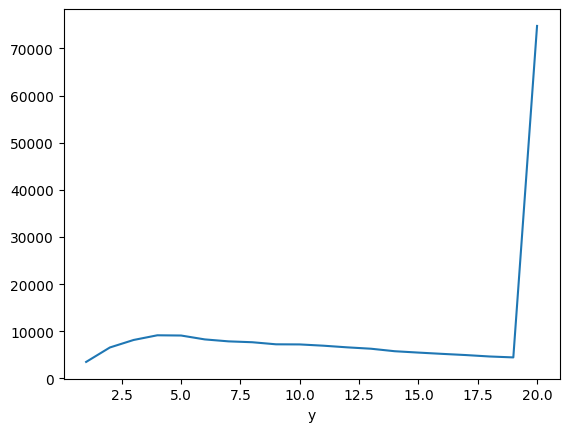

In [109]:
_sdf.groupby("y").count()["pred"].loc[1:,].plot()

<Axes: xlabel='y'>

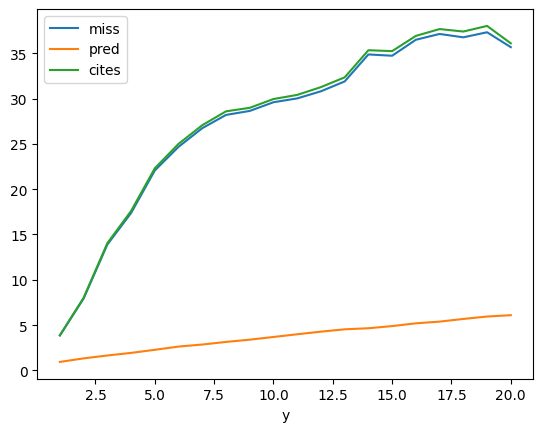

In [110]:
_sdf.groupby("y").agg("std").loc[:35, :].plot()

In [111]:
from ccl_science_data.common import GenReader, get_arr

In [112]:
gr = GenReader("..")

In [113]:
recs = []
j = 0
for i, name in enumerate(gr.get_names(EntC.SUBFIELDS)):
    if i in dropsuf:
        recs.append({"name": name})
        continue
    recs.append({"name": name, "decay": float(beta[j]), "volume": float(alpha[j])})
    j += 1

In [114]:
pdf = pd.DataFrame(recs).sort_values("volume", ascending=False)

In [115]:
pdf.head()

,name,decay,volume
28,Materials Chemistry,0.522366,20.702303
58,Computer Networks and Communications,0.622132,19.654594
29,Sociology and Political Science,0.562895,19.611868
33,Artificial Intelligence,0.565355,18.747562
46,Cardiology and Cardiovascular Medicine,0.527414,17.356670


In [116]:
pdf.tail(30)

,name,decay,volume
188,Linguistics and Language,0.763490,2.029678
14,Biophysics,0.653518,2.019004
118,Anthropology,0.753139,1.974746
213,Energy Engineering and Power Technology,0.761805,1.929025
243,Space and Planetary Science,0.749152,1.749097
216,Family Practice,0.590880,1.705037
232,Library and Information Sciences,0.631595,1.659545
204,Toxicology,0.643408,1.651137
212,Forestry,0.726287,1.639337
189,"Physical Therapy, Sports Therapy and Rehabilit...",0.768434,1.609158


In [211]:
pdf.set_index("name").corr()

,decay,volume
decay,1.000000,-0.790819
volume,-0.790819,1.000000
